In [ ]:
!pip install -q ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully!
Features shape: (303, 13)
Target shape: (303, 1)


In [ ]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [ ]:
y = y.iloc[:, 0]

y_binary = (y > 0).astype(int)

print("Target distribution:")
print(y_binary.value_counts())

Target distribution:
num
0    164
1    139
Name: count, dtype: int64


In [ ]:
df = X.copy()

df["target"] = y_binary

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


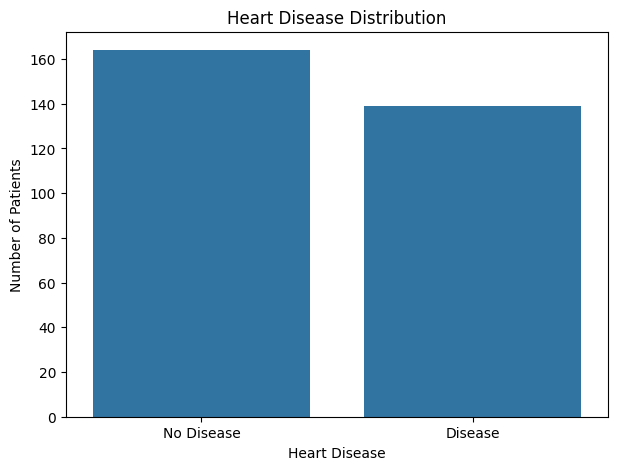

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="target"
)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.show()

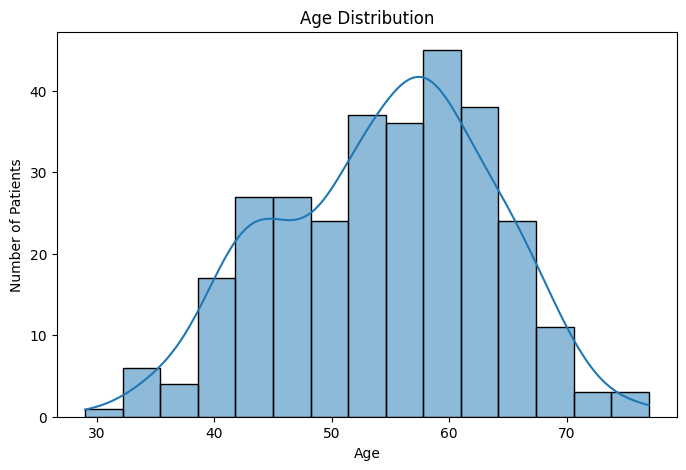

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    bins=15,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

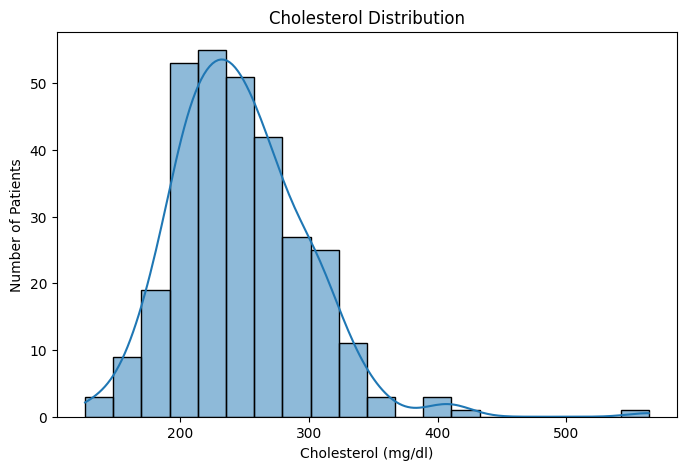

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="chol",
    bins=20,
    kde=True
)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol (mg/dl)")
plt.ylabel("Number of Patients")

plt.show()

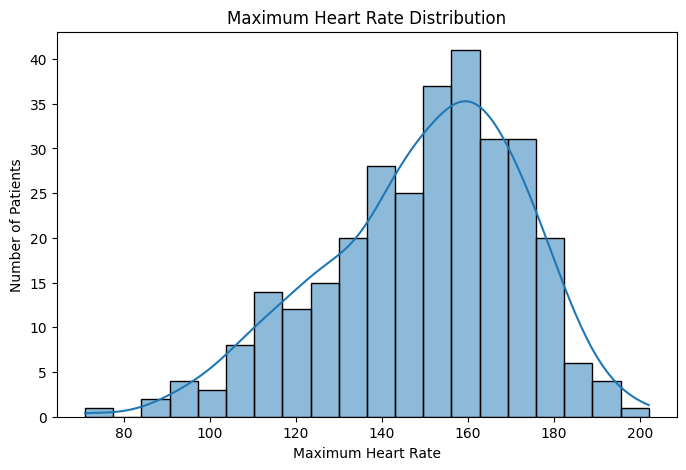

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="thalach",
    bins=20,
    kde=True
)

plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Maximum Heart Rate")
plt.ylabel("Number of Patients")

plt.show()

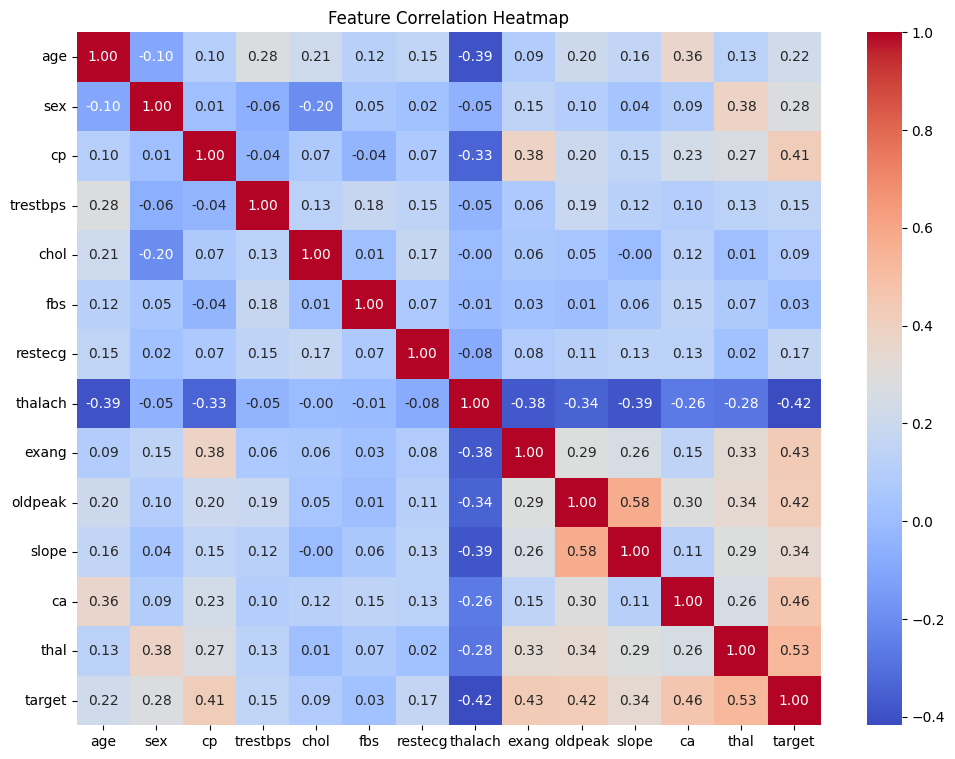

In [ ]:
plt.figure(figsize=(12, 9))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [ ]:
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "ca"
]

categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
]

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [ ]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

print("Pipeline created successfully!")

Pipeline created successfully!


In [ ]:
print("Training model...")

pipeline.fit(
    X_train,
    y_train
)

print("Model training completed!")

Training model...
Model training completed!


In [ ]:
y_pred = pipeline.predict(X_test)

y_probability = pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated!")

Predictions generated!


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MODEL PERFORMANCE")
print("-------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

MODEL PERFORMANCE
-------------------------
Accuracy : 0.8852
Precision: 0.8387
Recall   : 0.9286
F1 Score : 0.8814


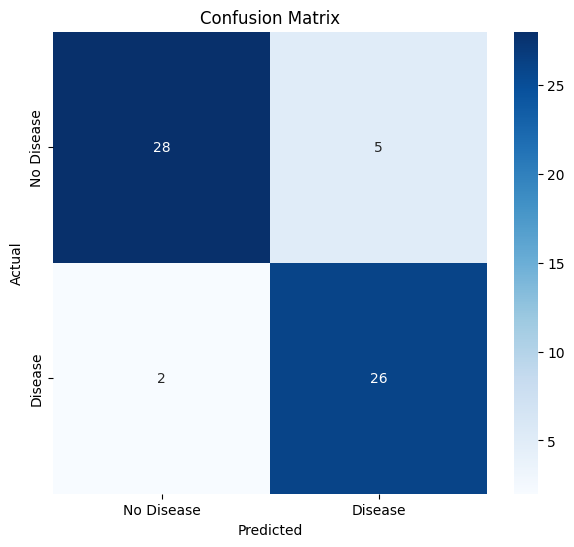

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

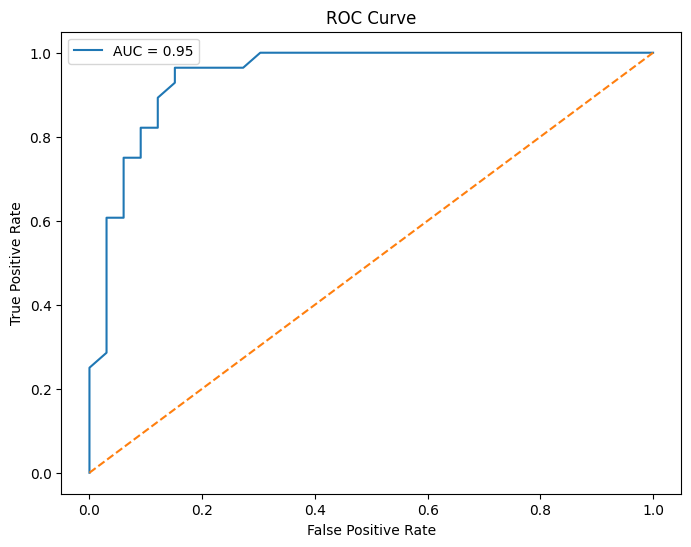

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

auc_score = roc_auc_score(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Disease",
            "Disease"
        ]
    )
)

              precision    recall  f1-score   support

  No Disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [ ]:
joblib.dump(
    pipeline,
    "heart_disease_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files

files.download(
    "heart_disease_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save the processed dataset
df.to_csv("heart_disease_data.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [ ]:
from google.colab import files

files.download("heart_disease_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>